## NESTLE STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

nestle=pd.read_csv('../stock_data/nestle.csv') ## so it can be small letter. This is cool.
nestle=nestle.drop(columns=['high_price','low_price'])
nestle.rename(columns={'trade_date':'date'},inplace=True)
nestle['date']=pd.to_datetime(nestle['date'])
nestle['month']=nestle['date'].dt.month
nestle['quarter']=nestle['date'].dt.quarter
nestle['year']=nestle['date'].dt.year

nestle

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42800,NESTLE,2017-01-03,810.0,810.0,16573,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43360,NESTLE,2017-01-04,810.0,810.0,13226,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43470,NESTLE,2017-01-05,810.0,810.0,64271,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43580,NESTLE,2017-01-06,809.0,809.0,202725,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43670,NESTLE,2017-01-09,809.0,809.0,15010,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298106,NESTLE,2026-07-13,3125.0,3125.0,18487,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298544,NESTLE,2026-07-14,3125.0,3125.0,71243,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298982,NESTLE,2026-07-15,3125.0,3125.0,4093,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299420,NESTLE,2026-07-16,3125.0,3125.0,39730,2026-07-16T15:10:03.113936+00:00,7,3,2026


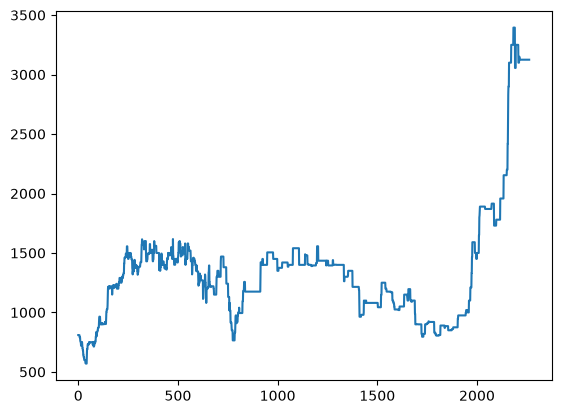

In [2]:
import matplotlib.pyplot as plt

plt.plot(nestle['close_price'])
plt.show()

In [3]:
nestle_end_month_df = (
    nestle
    .sort_values("date")
    .groupby(nestle["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

nestle_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45370,NESTLE,2017-01-31,727.00,727.00,128840,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47191,NESTLE,2017-02-28,570.00,570.00,645835,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49307,NESTLE,2017-03-31,750.00,750.00,121433,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51135,NESTLE,2017-04-28,727.00,727.00,156917,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53057,NESTLE,2017-05-31,875.01,875.01,134271,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35343,NESTLE,2026-03-31,3395.00,3395.00,392064,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281169,NESTLE,2026-04-30,3100.00,3100.00,33329,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284235,NESTLE,2026-05-29,3125.00,3125.00,10245,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294163,NESTLE,2026-06-30,3125.00,3125.00,81927,2026-06-30T15:10:03.08168+00:00,6,2,2026


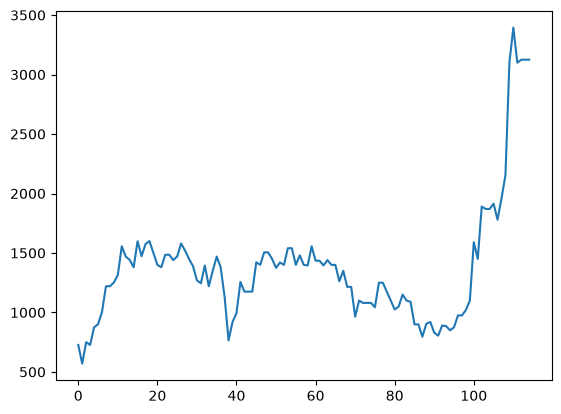

In [4]:
plt.plot(nestle_end_month_df['close_price'])
plt.show()

In [5]:
nestle_end_month_df['returns']=nestle_end_month_df['close_price'].pct_change()*100
nestle_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45370,NESTLE,2017-01-31,727.00,727.00,128840,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47191,NESTLE,2017-02-28,570.00,570.00,645835,2026-04-08T02:44:45.006295+00:00,2,1,2017,-21.595598
2,49307,NESTLE,2017-03-31,750.00,750.00,121433,2026-04-08T02:45:42.281198+00:00,3,1,2017,31.578947
3,51135,NESTLE,2017-04-28,727.00,727.00,156917,2026-04-08T02:51:55.619599+00:00,4,2,2017,-3.066667
4,53057,NESTLE,2017-05-31,875.01,875.01,134271,2026-04-08T02:52:57.421655+00:00,5,2,2017,20.359010
...,...,...,...,...,...,...,...,...,...,...,...
110,35343,NESTLE,2026-03-31,3395.00,3395.00,392064,2026-03-31T15:00:02.085058+00:00,3,1,2026,9.516129
111,281169,NESTLE,2026-04-30,3100.00,3100.00,33329,2026-04-30T15:00:02.170664+00:00,4,2,2026,-8.689249
112,284235,NESTLE,2026-05-29,3125.00,3125.00,10245,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.806452
113,294163,NESTLE,2026-06-30,3125.00,3125.00,81927,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


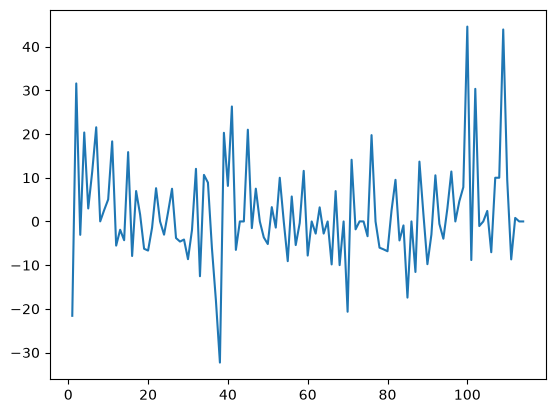

In [6]:
plt.plot(nestle_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(nestle_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-6.547402961697957), np.float64(9.02705249089083e-09), 2, 111, {'1%': np.float64(-3.490683082754047), '5%': np.float64(-2.8879516565798817), '10%': np.float64(-2.5808574442009578)}, np.float64(769.9902982712333))
stationary


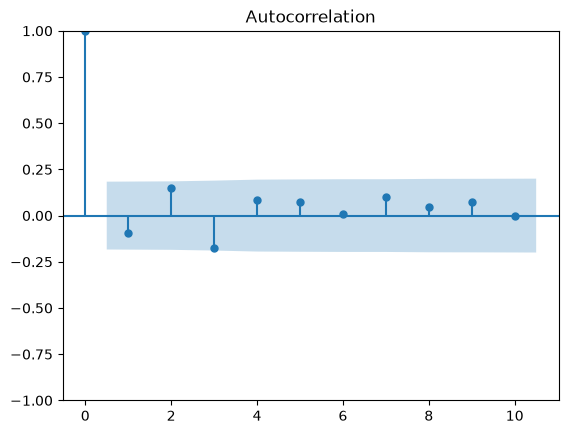

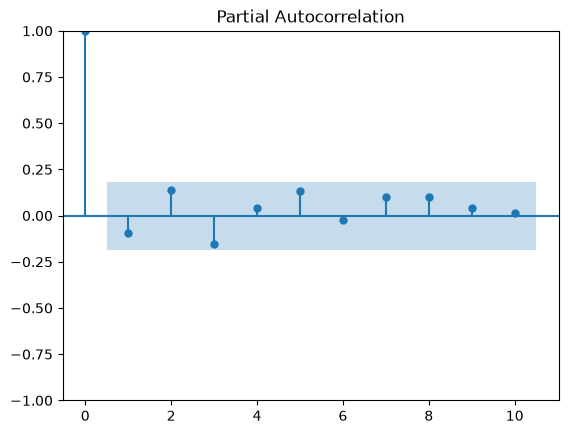

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(nestle_end_month_df['returns'].dropna(), lags=10)
plot_pacf(nestle_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nestle_end_month_df['close_price'][:-10]
test=nestle_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -19.635998425888562]
[0, 0, 0, 0, 0, 1, -10.212382842694185]
[0, 0, 0, 0, 0, 2, -9.203561314906565]
[0, 0, 0, 0, 1, 0, -5.936999506991432]
[0, 0, 0, 0, 1, 1, -5.842774831227636]
[0, 0, 0, 0, 1, 2, -5.790204005600197]
[0, 0, 0, 0, 2, 0, -4.628612644370979]
[0, 0, 0, 0, 2, 1, -5.56558860048037]
[0, 0, 0, 0, 2, 2, -8.591597386289079]
[0, 0, 0, 1, 0, 0, -6.394864051520357]
[0, 0, 0, 1, 0, 1, -5.902015966604069]
[0, 0, 0, 1, 0, 2, -5.8906386525726795]
[0, 0, 0, 1, 1, 0, -6.613988947059529]
[0, 0, 0, 1, 1, 1, -5.859878293581676]
[0, 0, 0, 1, 1, 2, -5.570812096015399]
[0, 0, 0, 1, 2, 0, -5.422430153204731]
[0, 0, 0, 1, 2, 1, -5.730344029269656]
[0, 0, 0, 1, 2, 2, -5.565227021277196]
[0, 0, 0, 2, 0, 0, -7.110682341984111]
[0, 0, 0, 2, 0, 1, -5.92292503195435]
[0, 0, 0, 2, 0, 2, -5.6135069720761495]
[0, 0, 0, 2, 1, 0, -6.147927884544448]
[0, 0, 0, 2, 1, 1, -5.819104421351041]
[0, 0, 0, 2, 1, 2, -6.479629326887708]
[0, 0, 0, 2, 2, 0, -7.075953473856595]
[0, 0, 0, 2, 2, 1, -7.0

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-19.635998
54,0,0,2,0,0,0,-18.910045
27,0,0,1,0,0,0,-18.737858
65,0,0,2,1,0,2,-12.303428
38,0,0,1,1,0,2,-11.011036
...,...,...,...,...,...,...,...
440,1,2,1,0,2,2,0.502067
457,1,2,1,2,2,1,0.510834
665,2,2,0,1,2,2,0.516670
241,0,2,2,2,2,1,0.525965


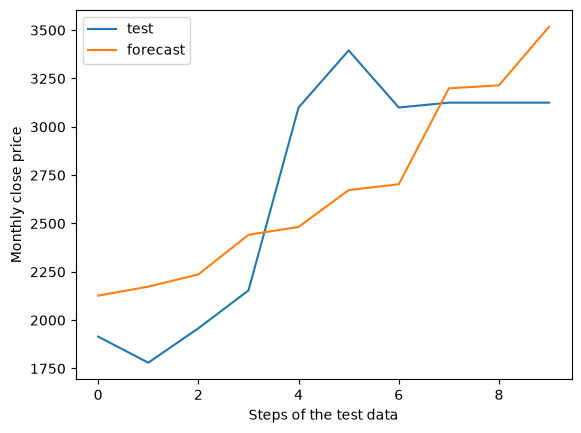

r2_score:  0.5649063339650392
rmse:  398.58739556313895
description:  count     115.000000
mean     1370.647043
std       513.514819
min       570.000000
25%      1080.200000
50%      1375.000000
75%      1476.250000
max      3395.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=nestle_end_month_df['close_price'][:-10]
y_test=nestle_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(2,2,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nestle_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nestle_end_month_df['returns'].dropna()[:-10]
test=nestle_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.18734916500329768]
[0, 0, 0, 0, 0, 1, -0.19081116281447041]
[0, 0, 0, 0, 0, 2, -0.37692633246853857]
[0, 0, 0, 0, 1, 0, -1.6316986103725846]
[0, 0, 0, 0, 1, 1, -0.5549616617710531]
[0, 0, 0, 0, 1, 2, -0.5559283408737141]
[0, 0, 0, 0, 2, 0, -5.685523936428079]
[0, 0, 0, 0, 2, 1, -1.8128534245471424]
[0, 0, 0, 0, 2, 2, -1.8248822628940768]
[0, 0, 0, 1, 0, 0, -0.192909070256287]
[0, 0, 0, 1, 0, 1, -0.26944386462532677]
[0, 0, 0, 1, 0, 2, -0.39950125479445764]
[0, 0, 0, 1, 1, 0, -1.0262603416574154]
[0, 0, 0, 1, 1, 1, -0.6196642046677496]
[0, 0, 0, 1, 1, 2, -0.6611627335518779]
[0, 0, 0, 1, 2, 0, -2.864737402165014]
[0, 0, 0, 1, 2, 1, -1.5545661106884028]
[0, 0, 0, 1, 2, 2, -1.6845383540769725]
[0, 0, 0, 2, 0, 0, -0.37528089263052]
[0, 0, 0, 2, 0, 1, -0.3858824271263206]
[0, 0, 0, 2, 0, 2, -0.23115225312594623]
[0, 0, 0, 2, 1, 0, -0.8508845503518563]
[0, 0, 0, 2, 1, 1, -0.7478153525980564]
[0, 0, 0, 2, 1, 2, -0.756359482474068]
[0, 0, 0, 2, 2, 0, -2.412857220578486]
[

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-258.664132
177,0,2,0,1,2,0,-176.808824
420,1,2,0,1,2,0,-164.784585
168,0,2,0,0,2,0,-149.570633
412,1,2,0,0,2,1,-143.713477
...,...,...,...,...,...,...,...
136,0,1,2,0,0,1,-0.012620
135,0,1,2,0,0,0,-0.011923
360,1,1,1,1,0,0,-0.004997
352,1,1,1,0,0,1,-0.004033


Very horrible. We will work with close_price
